# Workload Runtime Distributions -- Ours vs. Baselines

Read-only visualization notebook: for every leg with a clean execution run,
loads every query's raw runtime (`runtime_s`) directly from the lakehouse
execution traces and plots how that leg's runtime distribution compares to
the others. Companion to
[`diversql_qpp_strengths.ipynb`](diversql_qpp_strengths.ipynb) (which
compares *QPP model* performance across legs) -- this one compares the
*workloads themselves*, before any model touches them.

**Why log scale.** Runtime is heavy-tailed within every leg (a handful of
queries run 100-1000x longer than the median) -- see the `max_q_error` /
log-metric discussion in `qpp_full_baseline_training.ipynb`. Every plot
below is on a log runtime axis so the bulk of the distribution and the
tail are both visible at once.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent.parent   # /mnt/primary/Main
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from uncertainty_prediction.new_config import PARSED_RESULTS_ROOT, METRIC, XCOL, YCOL
from uncertainty_prediction.src import canon_qid
from loader.load import load_aligned_plans_and_runs

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## Config

Same `LEGS` roster (collection, run_ids, Vendi score) and `OURS`/`LEG_COLORS`
convention as `qpp_full_baseline_training.ipynb` and
`diversql_qpp_strengths.ipynb` -- kept in sync by hand across the three
notebooks. No train/test split here (this notebook plots the full workload,
not a held-out slice), so `fixed_test_qids` isn't needed.

In [2]:
SCHEMA_NAME = "tpcds"
LAKEHOUSE_INSTANCE_NAME = "lakehouse-h"
OURS = ["gpt_generated", "gpt_generated_no_feedback"]
OURS_LABELS = {
    "gpt_generated": "DiverSQL (W/ Feedback)",
    "gpt_generated_no_feedback": "DiverSQL (W/O Feedback)",
}

# Canonical display names, matching the paper/README stylization of each
# baseline (workload_generation/README.md), not the raw collection keys.
DISPLAY_NAMES = {
    "tpcds": "TPC-DS",
    "sqlbarber": "SQLBarber",
    "bootstrapping_lcm": "Bootstrapping-LCM",
    "sql_factory": "SQL-Factory",
    "e2etune": "E2ETune",
    "sqlstorm": "SQLStorm",
    **OURS_LABELS,
}


def display_name(leg):
    return DISPLAY_NAMES.get(leg, leg)


def queries_dir_for(root: str, run_id: str) -> str:
    return f"{root}/{SCHEMA_NAME}/{LAKEHOUSE_INSTANCE_NAME}/{run_id}/queries"


# Tried in order; the second root isn't mounted on every pod (only where a
# PVC for it was attached), so a run whose raw output only landed there is
# silently unavailable on pods without it -- see the [missing] print below.
DATA_ROOTS = [
    "/mnt/lakehouse-raw-results",
    "/mnt/lakehouse-raw-results-2",
]

LEGS = {
    "tpcds": dict(collection="tpcds_1200", run_ids=["20260816-120034Z"], vendi=22.72),
    "sqlbarber": dict(collection="sqlbarber_1000_tokens_tpcds", run_ids=["20260818-033107Z"], vendi=16.38),
    "bootstrapping_lcm": dict(collection="bootstrapping_lcm_1000_tokens_tpcds", run_ids=["20260816-171633Z"], vendi=18.98),
    "sql_factory": dict(collection="sql_factory_1000_tokens_tpcds", run_ids=["20260817-133213Z"], vendi=52.44),
    "e2etune": dict(collection="e2etune_1000_tokens_tpcds", run_ids=["20260817-044319Z"], vendi=55.32),
    "sqlstorm": dict(collection="sqlstorm_1000_tokens_tpcds_new", run_ids=["20260819-161625Z"], vendi=77.64),  
    "gpt_generated": dict(collection="gpt_generated_1000_tpcds_tokens", run_ids=["20260813-214605Z"], vendi=106.06),
    "gpt_generated_no_feedback": dict(collection="gpt_generated_1000_tpcds_tokens_no_feedback", run_ids=["20260921-111847Z"], vendi=87.10),
}

# Matches structural_collapse_plot.ipynb's COL dict: same hue per baseline;
# the two DiverSQL variants share the orange family (same system, feedback
# on/off) at different lightness rather than two unrelated hues.
LEG_COLORS = {
    "tpcds": "#9ca3af",
    "sqlbarber": "#a855f7",
    "bootstrapping_lcm": "#6366f1",
    "sql_factory": "#0891b2",
    "e2etune": "#059669",
    "sqlstorm": "#db2777",
    "gpt_generated": "#ea580c",              # orange (DiverSQL, w/ feedback)
    "gpt_generated_no_feedback": "#f59e0b",  # amber (DiverSQL, w/o feedback)
}

print(f"{len(LEGS)} legs configured; Vendi range "
      f"{min(l['vendi'] for l in LEGS.values())}-{max(l['vendi'] for l in LEGS.values())}")

8 legs configured; Vendi range 16.38-106.06


## Load raw per-query runtimes

One run-level `runtime_s` value per query execution, straight from the
aligned execution traces -- no train/test split, no model involved. Legs
with no recorded run (e.g. `sqlstorm`) are skipped with a printed reason
rather than aborting the whole notebook, matching the lenient-loading
convention used in `qpp_full_baseline_training.ipynb`.

In [3]:
def load_leg_runtimes(leg_specs, *, schema, instance, metric, xcol, ycol, parsed_results_root, data_roots):
    runtimes, skipped = {}, []

    for name, spec in leg_specs.items():
        run_ids = spec.get("run_ids") or []
        if not run_ids:
            print(f"[missing] {name} ({spec['collection']}): no execution run recorded yet -- skipping.")
            skipped.append(name)
            continue

        runs_by_query = common = None
        misses = []
        for root in data_roots:
            queries_dir = Path(queries_dir_for(root, run_ids[0]))
            if not queries_dir.is_dir():
                misses.append(f"{root}: not found (root unmounted here, or run's raw output lives elsewhere)")
                continue
            try:
                _, runs_by_query, common = load_aligned_plans_and_runs(
                    queries_dir=queries_dir,
                    run_ids=run_ids,
                    collection=spec["collection"],
                    schema=schema,
                    instance=instance,
                    metric=metric,
                    xcol=xcol,
                    ycol=ycol,
                    parsed_results_root=parsed_results_root,
                    canon_fn=canon_qid,
                    use_scalar_runtime=True,
                )
                break  # got it, stop trying other roots
            except Exception as e:
                misses.append(f"{root}: {type(e).__name__}: {e}")

        if runs_by_query is None or not common:
            reason = "; ".join(misses) if misses else "run dir found but no plans matched runtimes.csv"
            print(f"[missing] {name} ({spec['collection']}): {reason} -- skipping.")
            skipped.append(name)
            continue

        vals = np.array(
            [df["runtime_s"].iloc[0] for q in common for df in runs_by_query[q]],
            dtype=float,
        )
        runtimes[name] = vals
        print(f"{name}: {len(vals)} runs loaded ({len(common)} distinct queries)")

    return runtimes, skipped


RUNTIMES, SKIPPED_LEGS = load_leg_runtimes(
    LEGS,
    schema=SCHEMA_NAME,
    instance=LAKEHOUSE_INSTANCE_NAME,
    metric=METRIC,
    xcol=XCOL,
    ycol=YCOL,
    parsed_results_root=PARSED_RESULTS_ROOT,
    data_roots=DATA_ROOTS,
)

# Ordered by Vendi score ascending, matching the other two notebooks' x-axis order.
AVAILABLE_LEGS = RUNTIMES.keys()

print()
print(f"available legs ({len(AVAILABLE_LEGS)}/{len(LEGS)}):",
      [f"{n} (Vendi {LEGS[n]['vendi']})" for n in AVAILABLE_LEGS])
if SKIPPED_LEGS:
    print(f"skipped ({len(SKIPPED_LEGS)}/{len(LEGS)}):", SKIPPED_LEGS)

tpcds: 1208 runs loaded (1208 distinct queries)
sqlbarber: 982 runs loaded (982 distinct queries)
bootstrapping_lcm: 971 runs loaded (971 distinct queries)
sql_factory: 972 runs loaded (972 distinct queries)
e2etune: 989 runs loaded (989 distinct queries)
sqlstorm: 922 runs loaded (922 distinct queries)
gpt_generated: 949 runs loaded (949 distinct queries)
gpt_generated_no_feedback: 970 runs loaded (970 distinct queries)

available legs (8/8): ['sqlbarber (Vendi 16.38)', 'bootstrapping_lcm (Vendi 18.98)', 'tpcds (Vendi 22.72)', 'sql_factory (Vendi 52.44)', 'e2etune (Vendi 55.32)', 'sqlstorm (Vendi 77.64)', 'gpt_generated_no_feedback (Vendi 87.1)', 'gpt_generated (Vendi 106.06)']


## 1. Overlaid runtime distributions (step histogram, log scale)

Density-normalized so legs with different query counts are still
comparable. `Ours` is drawn with a bolder line and higher z-order so it
stays visible against the others.

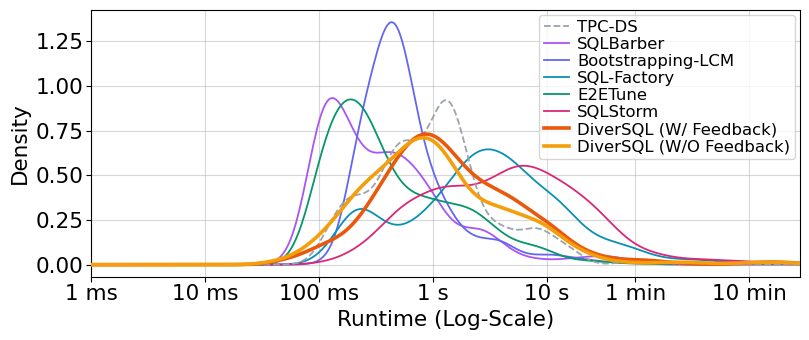

In [6]:
from scipy.stats import gaussian_kde

# "Nice" time units for the log-scale x-axis, matching the SQLStorm paper's
# runtime-distribution figure convention (ms -> s -> min -> hr, not bare
# decades of seconds -- e.g. "1 min" / "10 min" rather than "60 s" / "600 s").
NICE_TIME_TICKS = [
    (1e-3, "1 ms"), (1e-2, "10 ms"), (1e-1, "100 ms"),
    (1, "1 s"), (10, "10 s"),
    (60, "1 min"), (600, "10 min"),
    (3600, "1 hr"),
]

font_size = 15.5
font_size_leg = 11.85

AVAILABLE_LEGS = RUNTIMES.keys()

fig, ax = plt.subplots(figsize=(8.2, 3.5))

all_vals = np.concatenate([RUNTIMES[n] for n in AVAILABLE_LEGS])
log_lo = min(np.log10(all_vals.min()), np.log10(1e-3))  # always report from 1 ms, even if no data there
log_hi = np.log10(all_vals.max())
log_grid = np.linspace(log_lo, log_hi, 400)
grid = 10 ** log_grid

for name in AVAILABLE_LEGS:
    is_ours = name in OURS
    is_reference = name == "tpcds"  # real-query baseline -- dashed, like TPC-DS in the reference figure
    density = gaussian_kde(np.log10(RUNTIMES[name]))(log_grid)
    ax.plot(
        grid, density,
        linewidth=2.6 if is_ours else 1.3,
        linestyle="--" if is_reference else "-",
        color=LEG_COLORS.get(name, "#9ca3af"),
        label=display_name(name),
        zorder=5 if is_ours else (4 if is_reference else 3),
    )

ax.set_xscale("log")
from matplotlib.ticker import NullLocator

ax.xaxis.set_minor_locator(NullLocator())
ticks = [t for t, _ in NICE_TIME_TICKS if log_lo <= np.log10(t) <= log_hi]
ax.set_xticks(ticks)
ax.set_xticklabels([label for t, label in NICE_TIME_TICKS if t in ticks])
ax.set_xlim(10 ** log_lo, 10 ** log_hi)
ax.set_xlabel("Runtime (Log-Scale)", fontsize=font_size)
ax.set_ylabel("Density", fontsize=font_size)
ax.grid(linestyle='-', alpha=0.5)
ax.legend(
    fontsize=font_size_leg,
    labelspacing=0.125,   # vertical space between entries (default 0.5)
    handlelength=1.5,   # length of the line sample (default 2.0)
    handletextpad=0.5,  # space between line sample and text (default 0.8)
    borderpad=0.3,       # padding inside the legend box (default 0.4)
    borderaxespad=0.3,   # space between legend and axes (default 0.5)
)
ax.tick_params(axis='x', labelsize=font_size, pad=2)
ax.tick_params(axis='y', labelsize=font_size, pad=2)



plt.tight_layout()
plt.savefig("results/figures/runtimes.pdf")

plt.show()

## 2. Runtime spread per leg (violin plot, ordered by Vendi score)

Same data, shape-focused view: median, IQR and tails per leg side by
side, x-axis ordered by structural diversity (Vendi score) ascending --
same convention as the dose-response notebook.

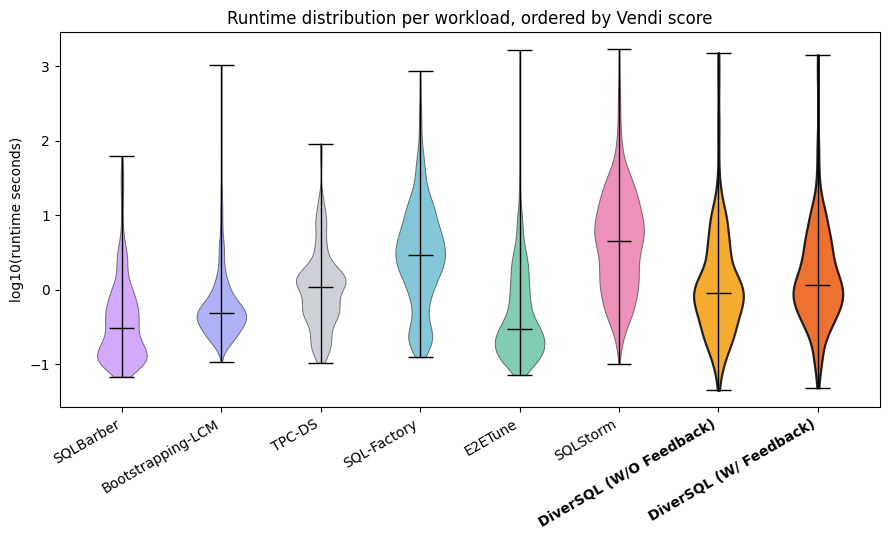

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))

log_data = [np.log10(RUNTIMES[name]) for name in AVAILABLE_LEGS]
parts = ax.violinplot(log_data, showmedians=True)

for i, body in enumerate(parts["bodies"]):
    name = AVAILABLE_LEGS[i]
    is_ours = name in OURS
    body.set_facecolor(LEG_COLORS.get(name, "#9ca3af"))
    body.set_alpha(0.85 if is_ours else 0.5)
    body.set_edgecolor("black")
    body.set_linewidth(1.6 if is_ours else 0.7)

for part_name in ("cmedians", "cmins", "cmaxes", "cbars"):
    if part_name in parts:
        parts[part_name].set_color("black")
        parts[part_name].set_linewidth(1.0)

ax.set_xticks(range(1, len(AVAILABLE_LEGS) + 1))
ax.set_xticklabels([display_name(n) for n in AVAILABLE_LEGS], rotation=30, ha="right")
for label in ax.get_xticklabels():
    if label.get_text() in OURS_LABELS.values():
        label.set_fontweight("bold")

ax.set_ylabel("log10(runtime seconds)")
ax.set_title("Runtime distribution per workload, ordered by Vendi score")
plt.tight_layout()
plt.show()

## 3. Runtime ECDF

Cumulative view -- most direct way to see *where* two distributions
diverge (bulk vs. tail) rather than just that they differ.

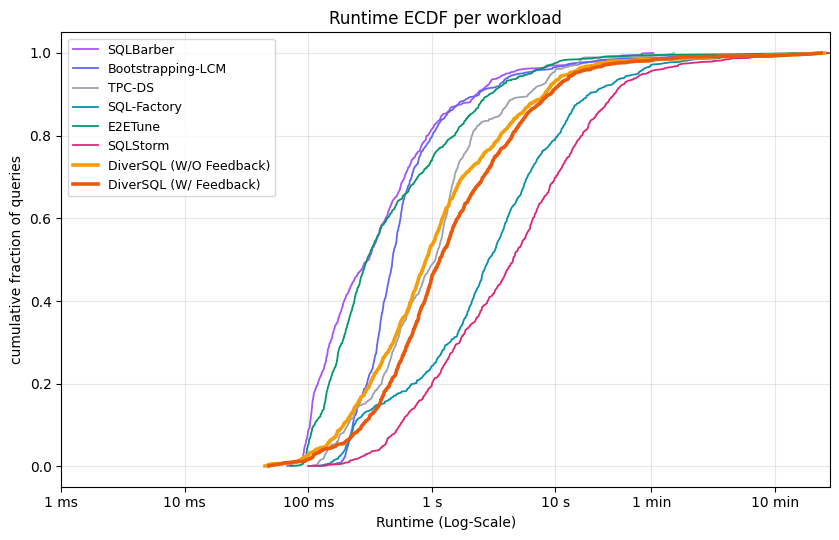

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

for name in AVAILABLE_LEGS:
    vals = np.sort(RUNTIMES[name])
    y = np.arange(1, len(vals) + 1) / len(vals)
    is_ours = name in OURS
    ax.plot(
        vals, y, color=LEG_COLORS.get(name, "#9ca3af"),
        linewidth=2.6 if is_ours else 1.3,
        label=display_name(name),
        zorder=5 if is_ours else 3,
    )

ax.set_xscale("log")
from matplotlib.ticker import NullLocator

# Same tick convention as plot 1 (NICE_TIME_TICKS, ms -> s -> min -> hr)
# instead of bare log-decade labels, so the two plots read as one axis.
all_vals = np.concatenate([RUNTIMES[n] for n in AVAILABLE_LEGS])
log_lo = min(np.log10(all_vals.min()), np.log10(1e-3))  # always report from 1 ms, even if no data there
log_hi = np.log10(all_vals.max())
ax.xaxis.set_minor_locator(NullLocator())
ticks = [t for t, _ in NICE_TIME_TICKS if log_lo <= np.log10(t) <= log_hi]
ax.set_xticks(ticks)
ax.set_xticklabels([label for t, label in NICE_TIME_TICKS if t in ticks])
ax.set_xlim(10 ** log_lo, 10 ** log_hi)
ax.set_xlabel("Runtime (Log-Scale)")
ax.set_ylabel("cumulative fraction of queries")
ax.set_title("Runtime ECDF per workload")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Summary statistics

In [18]:
rows = []
for name in AVAILABLE_LEGS:
    vals = RUNTIMES[name]
    rows.append(dict(
        leg=display_name(name),
        n=len(vals),
        mean=float(np.mean(vals)),
        median=float(np.median(vals)),
        p90=float(np.percentile(vals, 90)),
        p99=float(np.percentile(vals, 99)),
        max=float(np.max(vals)),
    ))
summary = pd.DataFrame(rows)


def _highlight_ours(row):
    is_ours = row["leg"] in OURS_LABELS.values()
    return ["background-color: #fed7aa; font-weight: bold" if is_ours else "" for _ in row]


styled_summary = summary.style.apply(_highlight_ours, axis=1).format({
    "mean": "{:.3f}", "median": "{:.3f}", "p90": "{:.3f}", "p99": "{:.3f}", "max": "{:.3f}",
}).relabel_index(
    ["Dataset", "n", "mean (s)", "median (s)", "p90 (s)", "p99 (s)", "max (s)"], axis=1
).hide(axis="index")
styled_summary

Dataset,n,mean (s),median (s),p90 (s),p99 (s),max (s)
SQLBarber,982,1.573,0.308,2.300,33.343,62.276
Bootstrapping-LCM,971,6.482,0.481,2.411,81.864,1025.203
TPC-DS,1208,2.708,1.068,6.045,44.210,91.398
SQL-Factory,972,13.342,2.879,18.770,225.409,871.628
E2ETune,989,4.604,0.299,2.915,23.685,1624.303
SQLStorm,922,22.631,4.555,29.853,402.752,1675.757
DiverSQL (W/O Feedback),970,11.151,0.902,8.205,183.922,1513.515
DiverSQL (W/ Feedback),949,12.018,1.160,9.084,100.412,1418.145


## 5. Paper figure -- compact runtime-distribution summary

One panel, ECDF on a log runtime axis -- the standard systems-paper form
for "how does query latency compare across workloads," and the most
information-dense single view of where distributions diverge (bulk vs.
tail) without needing a separate table alongside it.

**Emphasis, not an 8-way categorical.** The story here is `DiverSQL` (both
feedback variants) vs. `tpcds` (the real reference workload) vs. the pool of
synthetic-generator baselines -- not "tell them all apart," which is what
plots 1-3 above are for. So only three lines get identity color (DiverSQL
W/ Feedback: orange; DiverSQL W/O Feedback: amber; `tpcds`: dashed dark
reference) and share one combined "DiverSQL (W/ & W/O Feedback)" legend
entry; the other five baselines share one muted gray as context,
individually still visible as distinct thin lines but not competing for
legend space. A dotted horizontal guide at the 50th percentile lets every
curve's median be read off directly, without per-curve text labels
cluttering the panel. Saved as both PNG (quick preview) and PDF (vector,
for `\includegraphics`) under `results/`.

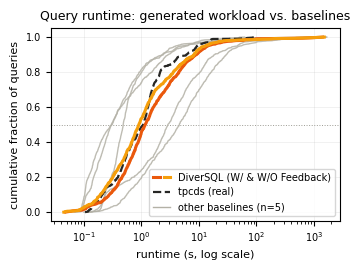

saved: /mnt/primary/Main/workload_generation/analysis/results/runtime_distribution_ecdf.png
saved: /mnt/primary/Main/workload_generation/analysis/results/runtime_distribution_ecdf.pdf


In [19]:
RESULTS_DIR = (Path.cwd() / "results").resolve()
RESULTS_DIR.mkdir(exist_ok=True)

# Validated categorical accent (dataviz skill default palette, slot 2
# "orange"/"amber") for the two DiverSQL variants -- now matching
# structural_collapse_plot.ipynb's COL dict instead of a one-off accent, so
# the same system reads as the same colour across every companion plot -- a
# dark reference tone for tpcds (real queries), and one muted gray for the
# remaining baselines as a de-emphasized group -- see the emphasis-form note
# above. NOT the same dict as LEG_COLORS (kept in sync by hand across the
# three companion notebooks for plots 1-3) -- this is scoped to this one
# paper figure only.
PAPER_ACCENT = "#ea580c"              # DiverSQL (W/ Feedback)
PAPER_ACCENT_NO_FEEDBACK = "#f59e0b"  # DiverSQL (W/O Feedback)
PAPER_REFERENCE = "#262624"   # tpcds
PAPER_CONTEXT = "#b3b1a6"     # other synthetic baselines, grouped

OTHER_BASELINES = [n for n in AVAILABLE_LEGS if n not in OURS and n != "tpcds"]

fig, ax = plt.subplots(figsize=(3.6, 2.8))

for name in OTHER_BASELINES:
    vals = np.sort(RUNTIMES[name])
    y = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, y, color=PAPER_CONTEXT, linewidth=1.0, alpha=0.85, zorder=2)

ax.axhline(0.5, color="#9c9b93", linewidth=0.7, linestyle=":", zorder=1)

legend_handles, legend_labels = [], []
if "tpcds" in RUNTIMES:
    vals = np.sort(RUNTIMES["tpcds"])
    y = np.arange(1, len(vals) + 1) / len(vals)
    (h_ref,) = ax.plot(vals, y, color=PAPER_REFERENCE, linewidth=1.6, linestyle="--", zorder=3)
    legend_handles.append(h_ref); legend_labels.append("tpcds (real)")

# Both DiverSQL variants get their own line (orange / amber) but share one
# combined legend entry -- "DiverSQL (W/ & W/O Feedback)" -- via
# HandlerTuple, the same grouping trick used for "other baselines" below, so
# the compact paper figure's legend doesn't grow just because there are now
# two DiverSQL lines instead of one.
ours_handles = []
for leg_name, color in zip(OURS, (PAPER_ACCENT, PAPER_ACCENT_NO_FEEDBACK)):
    vals = np.sort(RUNTIMES[leg_name])
    y = np.arange(1, len(vals) + 1) / len(vals)
    (h,) = ax.plot(vals, y, color=color, linewidth=2.2, zorder=5)
    ours_handles.append(h)

context_handle = plt.Line2D([0], [0], color=PAPER_CONTEXT, linewidth=1.0)

ax.set_xscale("log")
ax.set_xlabel("runtime (s, log scale)", fontsize=8)
ax.set_ylabel("cumulative fraction of queries", fontsize=8)
ax.set_title("Query runtime: generated workload vs. baselines", fontsize=9)
ax.tick_params(labelsize=7)
ax.grid(alpha=0.25, linewidth=0.5)

from matplotlib.legend_handler import HandlerTuple

ax.legend(
    [tuple(ours_handles), *legend_handles, context_handle],
    ["DiverSQL (W/ & W/O Feedback)", *legend_labels, f"other baselines (n={len(OTHER_BASELINES)})"],
    fontsize=7, loc="lower right", frameon=True, handlelength=1.8,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)

plt.tight_layout()

png_path = RESULTS_DIR / "runtime_distribution_ecdf.png"
pdf_path = RESULTS_DIR / "runtime_distribution_ecdf.pdf"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
fig.savefig(pdf_path, dpi=150, bbox_inches="tight")
plt.show()

print("saved:", png_path)
print("saved:", pdf_path)